# The Neuron, Perceptron, and XOR Problem

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand linear separability and the XOR problem
- Use multi-layer models to solve XOR

## 🔗 Where this fits

**Builds on:** Unit 3, lesson 01 "Regression vs Classification" — a linear classifier, pushed until it breaks on XOR.

**Used later in:** Course 08 (AIAT 122) — Unit 1, where the multi-layer fix is built and trained from scratch.

---


## 🎯 The four-row table that stopped neural networks for fifteen years

In July 1958 the New York Times reported on a US Navy demonstration of Frank
Rosenblatt's **perceptron** and told its readers the Navy expected the device to
be "the embryo of an electronic computer that will be able to walk, talk, see,
write, reproduce itself and be conscious of its existence". Rosenblatt's machine
was real and its learning rule worked — you will implement it in Unit 4.

In **1969** Marvin Minsky and Seymour Papert published *Perceptrons*, and among
its results was one small, devastating example: a single-layer perceptron
**cannot compute XOR**. Not "does badly on" — *cannot*, provably, for any weights
at all. Four rows of a truth table. Funding and interest in neural networks
collapsed and did not properly recover until backpropagation was popularised by
Rumelhart, Hinton and Williams in **1986** — a gap of roughly fifteen years.

The mathematics was correct and the conclusion drawn from it was too broad: the
proof was about *single-layer* perceptrons, and the fix — a hidden layer — was
already conceivable. What was missing was a practical way to train the hidden
layer. This notebook walks straight into that history: it shows you the wall, and
then shows you the door.

### What goes wrong without understanding linear separability

You will spend a week tuning a model that provably cannot represent the answer.
Linear separability is the property that decides whether *any* single-neuron
model — perceptron, logistic regression, linear SVM — can solve your problem. If
your classes cannot be split by a straight line (a plane, a hyperplane), no
learning rate, no number of epochs and no random seed will get you there, and the
model will not tell you why it is stuck.


# The Neuron, Perceptron, and XOR Problem

**Unit:** Unit 3: AI Concepts, Terminology, and Application Domains Part 2  

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand neuron structure and mathematics
- Learn activation functions (Sigmoid, ReLU)
- Understand perceptron limitations
- Solve the XOR problem using neural networks
- Implement XOR with Keras

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Anatomy of one artificial neuron: inputs are weighted, summed with a bias, and
# squashed by an activation function — the building block of every network in this course.
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

print("=== The Neuron and Perceptron ===")
print("\nNeuron Structure:")
print("  - Inputs (x₁, x₂, ..., xₙ)")
print("  - Weights (w₁, w₂, ..., wₙ)")
print("  - Bias (b)")
print("  - Activation function (σ)")
print("  - Output: σ(Σ(wᵢ·xᵢ) + b)")

print("\nActivation Functions:")
print("  - Sigmoid: σ(x) = 1/(1+e⁻ˣ)")
print("  - ReLU: f(x) = max(0, x)")
print("  - Tanh: tanh(x)")

=== The Neuron and Perceptron ===

Neuron Structure:
  - Inputs (x₁, x₂, ..., xₙ)
  - Weights (w₁, w₂, ..., wₙ)
  - Bias (b)
  - Activation function (σ)
  - Output: σ(Σ(wᵢ·xᵢ) + b)

Activation Functions:
  - Sigmoid: σ(x) = 1/(1+e⁻ˣ)
  - ReLU: f(x) = max(0, x)
  - Tanh: tanh(x)


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_52849/2549768825.py:89: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


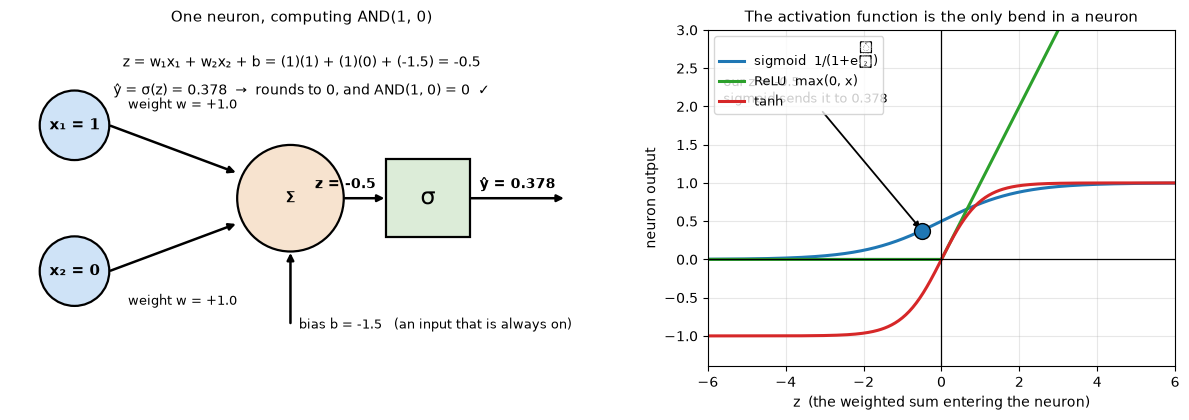

z = (1.0)(1) + (1.0)(0) + (-1.5) = -0.50
ŷ = sigmoid(-0.50) = 0.3775  →  rounds to 0

The same neuron on all four AND rows:
 x1  x2       z   sigma(z)  rounded   AND
  0   0    -1.5     0.1824        0     0
  0   1    -0.5     0.3775        0     0
  1   0    -0.5     0.3775        0     0
  1   1     0.5     0.6225        1     1

sigmoid outputs sit strictly inside (0, 1); ReLU is 0 for every negative z and
then rises with slope 1; tanh spans (-1, 1). All three are bent — that bend is
what a stack of layers needs, and it is exactly what the XOR section tests.


In [2]:
# The list above names the five parts of a neuron. Here they are as a picture, with a
# real set of weights doing a real calculation — an AND gate, the simplest perceptron
# there is, which is also the first panel of the separability figure further down.
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(t):
    """The squashing function named in the printout: maps any real number into (0, 1)."""
    return 1.0 / (1.0 + np.exp(-t))


# Weights and bias of a working AND perceptron, chosen by hand (not trained): the sum
# only clears the threshold when BOTH inputs are 1, because 1 + 1 - 1.5 > 0 while
# 1 + 0 - 1.5 < 0. We feed it the row x = (1, 0), which AND must answer 0.
w1, w2, b = 1.0, 1.0, -1.5
x1_in, x2_in = 1.0, 0.0
z = w1 * x1_in + w2 * x2_in + b          # the weighted sum, BEFORE the activation
y_hat = sigmoid(z)                        # the neuron's output, AFTER the activation

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.3),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# --- LEFT: the five parts, wired together, with this example's numbers on them ----
axL.set_xlim(0, 10.7)
axL.set_ylim(0, 6.7)
axL.set_aspect("equal")
axL.axis("off")

def node(ax, xy, r, label, fc):
    ax.add_patch(plt.Circle(xy, r, facecolor=fc, edgecolor="black", lw=1.6, zorder=3))
    ax.text(xy[0], xy[1], label, ha="center", va="center", fontsize=11,
            fontweight="bold", zorder=4)

IN1, IN2, SUM = (1.15, 4.3), (1.15, 1.7), (4.8, 3.0)
node(axL, IN1, 0.62, f"x₁ = {x1_in:.0f}", "#cfe3f7")
node(axL, IN2, 0.62, f"x₂ = {x2_in:.0f}", "#cfe3f7")
node(axL, SUM, 0.95, "Σ", "#f7e3cf")

arrow = dict(arrowstyle="-|>", lw=1.8, color="black", shrinkA=1, shrinkB=1)
for src, wgt, ylab in ((IN1, w1, 4.22), (IN2, w2, 1.78)):
    axL.annotate("", xy=(SUM[0] - 0.95, SUM[1] + (0.45 if src is IN1 else -0.45)),
                 xytext=(src[0] + 0.62, src[1]), arrowprops=arrow)
    # Sit the label on its own arrow: above the upper one, below the lower one.
    axL.text((src[0] + SUM[0]) / 2, ylab, f"w = {wgt:+.1f}", ha="center",
             va="bottom" if src is IN1 else "top", fontsize=10)
# The bias is an input that is always on — draw it as one, so it is not a mystery term.
axL.annotate("", xy=(SUM[0], SUM[1] - 0.95), xytext=(SUM[0], 0.75), arrowprops=arrow)
axL.text(SUM[0] + 0.15, 0.62, f"bias b = {b:+.1f}   (an input that is always on)",
         ha="left", va="bottom", fontsize=9.5)

# Sum -> activation -> output.
axL.add_patch(plt.Rectangle((7.0, 2.3), 1.5, 1.4, facecolor="#dcecd8",
                            edgecolor="black", lw=1.6, zorder=3))
axL.text(7.75, 3.0, "σ", ha="center", va="center", fontsize=17, zorder=4)
axL.annotate("", xy=(7.0, 3.0), xytext=(SUM[0] + 0.95, 3.0), arrowprops=arrow)
axL.text(6.37, 3.22, f"z = {z:+.1f}", ha="center", fontsize=10, fontweight="bold")
axL.annotate("", xy=(10.3, 3.0), xytext=(8.5, 3.0), arrowprops=arrow)
axL.text(9.4, 3.22, f"ŷ = {y_hat:.3f}", ha="center", fontsize=10, fontweight="bold")
axL.text(5.35, 6.25, f"z = w₁x₁ + w₂x₂ + b = "
                     f"({w1:.0f})({x1_in:.0f}) + ({w2:.0f})({x2_in:.0f}) + ({b:.1f}) = {z:+.1f}",
         ha="center", va="top", fontsize=10)
axL.text(5.35, 5.62, f"ŷ = σ(z) = {y_hat:.3f}  →  rounds to "
                     f"{int(y_hat > 0.5)}, and AND({x1_in:.0f}, {x2_in:.0f}) = 0  ✓",
         ha="center", va="top", fontsize=10)
axL.set_title("One neuron, computing AND(1, 0)", fontsize=11)

# --- RIGHT: the three activation shapes the printout named -----------------------
# WHY they matter: this curve is the ONLY non-linear part of a neuron. Remove it and a
# stack of layers collapses back into one straight line, which is the XOR story below.
t = np.linspace(-6, 6, 400)
axR.plot(t, sigmoid(t), lw=2.2, color="tab:blue", label="sigmoid  1 / (1 + exp(-z))")
axR.plot(t, np.maximum(0, t), lw=2.2, color="tab:green", label="ReLU  max(0, x)")
axR.plot(t, np.tanh(t), lw=2.2, color="tab:red", label="tanh")
axR.axhline(0, color="black", lw=0.9)
axR.axvline(0, color="black", lw=0.9)
# Put THIS neuron's z on the sigmoid curve, so the two panels are one story.
axR.scatter([z], [y_hat], s=130, color="tab:blue", edgecolor="black", zorder=5)
# Placed low and to the right: the only corner of this panel no curve passes through.
axR.annotate(f"our z = {z:+.1f}\nsigmoid sends it to {y_hat:.3f}",
             xy=(z, y_hat), xytext=(1.3, -1.15), fontsize=9.5,
             bbox=dict(fc="white", ec="0.6", boxstyle="round,pad=0.3"),
             arrowprops=dict(arrowstyle="-|>", lw=1.3, color="black"))
axR.set_xlim(-6, 6)
axR.set_ylim(-1.4, 3.0)
axR.set_xlabel("z  (the weighted sum entering the neuron)")
axR.set_ylabel("neuron output")
axR.set_title("The activation function is the only bend in a neuron", fontsize=11)
axR.legend(fontsize=9, loc="upper left")
axR.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# The same arithmetic as numbers, and the full truth table this neuron produces, so
# the picture can be checked rather than believed.
print(f"z = ({w1:.1f})({x1_in:.0f}) + ({w2:.1f})({x2_in:.0f}) + ({b:.1f}) = {z:+.2f}")
print(f"ŷ = sigmoid({z:+.2f}) = {y_hat:.4f}  →  rounds to {int(y_hat > 0.5)}\n")
print("The same neuron on all four AND rows:")
print(f"{'x1':>3} {'x2':>3} {'z':>7} {'sigma(z)':>10} {'rounded':>8} {'AND':>5}")
for a in (0, 1):
    for c in (0, 1):
        zz_ = w1 * a + w2 * c + b
        print(f"{a:>3} {c:>3} {zz_:>7.1f} {sigmoid(zz_):>10.4f} "
              f"{int(sigmoid(zz_) > 0.5):>8} {a & c:>5}")
print(f"\nsigmoid outputs sit strictly inside (0, 1); ReLU is 0 for every negative z and")
print(f"then rises with slope 1; tanh spans (-1, 1). All three are bent — that bend is")
print(f"what a stack of layers needs, and it is exactly what the XOR section tests.")


### 📊 What to see in the two panels above

**Left panel — the five parts from the list, wired up and carrying real numbers.**
Two inputs arrive, each is multiplied by a weight, the bias is added as if it were a
third input that is permanently switched on, and the single number `z` that comes out
of the Σ node is handed to the activation σ. The weights here are not trained; they
were chosen by hand so the neuron implements AND, and the printed truth table under
the figure checks all four rows. Read the arithmetic written above the diagram:
1 + 0 − 1.5 = −0.5, which σ turns into 0.378, which rounds to 0 — and AND(1, 0) is
indeed 0. **This is the whole computation of a neuron; everything later in the diploma
is this diagram repeated.**

**Right panel — why the σ box is not decoration.** All three activation functions the
printout named are drawn on one axis, and the point to see is that **all three are
bent**. Sigmoid flattens towards 0 and 1 at the extremes, ReLU is dead flat for
negative z and then a straight ramp, tanh is a sigmoid stretched to run from −1 to 1.
The blue dot is this neuron's own `z = −0.5` landing on the sigmoid curve, so the two
panels are the same calculation seen twice.

**The link to the rest of the notebook.** Weights and bias can only rotate and shift a
straight line; that bend in the right panel is the only source of non-linearity a
network has. Take it away and stacking layers gains you nothing — a chain of straight
lines is still a straight line. The next section shows a problem that a straight line
provably cannot solve, which is why that bend decided fifteen years of the field.


## The XOR Problem


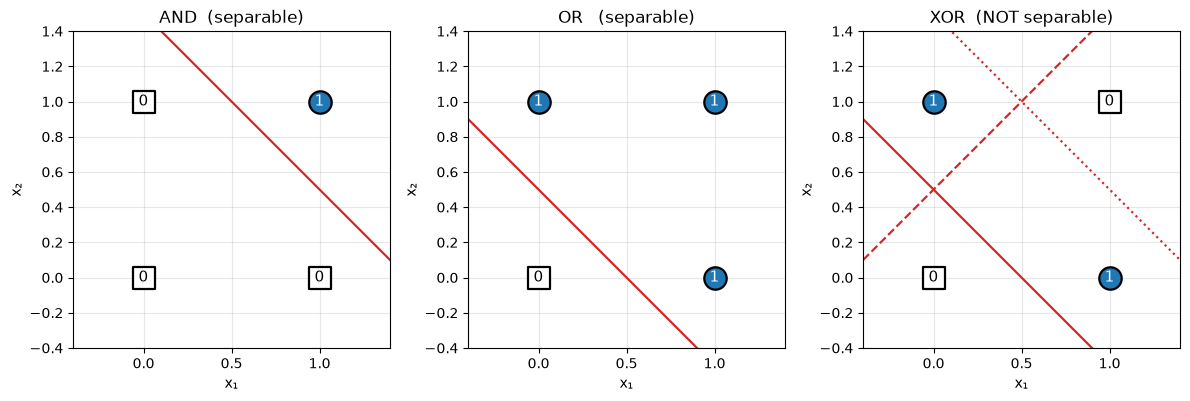

A single perceptron computes  step(w₁x₁ + w₂x₂ + b)  — one straight boundary.
For XOR the four corners demand all four of these at once:
   (0,0)→0:            b  < 0
   (0,1)→1:      w₂ + b  > 0
   (1,0)→1: w₁ +      b  > 0
   (1,1)→0: w₁ + w₂ + b  < 0
Add rows 2 and 3:  w₁ + w₂ + 2b > 0.  Row 1 says b < 0, so w₁ + w₂ + b > -b > 0.
That contradicts row 4 (w₁ + w₂ + b < 0). No weights exist. This is Minsky & Papert's proof,
in five lines — and the right-hand panel is the same fact with the algebra removed.


In [3]:
# BEFORE any training: WHY is XOR different? Linear separability is a property of the
# DATA, not of the model, so we can see the answer before a single weight is learned.
import numpy as np
import matplotlib.pyplot as plt

pts = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])       # the four corners of the square
targets = {                                             # three boolean functions of them
    "AND  (separable)": np.array([0, 0, 0, 1]),
    "OR   (separable)": np.array([0, 1, 1, 1]),
    "XOR  (NOT separable)": np.array([0, 1, 1, 0]),
}
# One hand-picked straight line per panel: w1*x1 + w2*x2 + b = 0, drawn as x2 = -(w1*x1+b)/w2.
lines = {
    "AND  (separable)": [(1.0, 1.0, -1.5)],            # one line is enough
    "OR   (separable)": [(1.0, 1.0, -0.5)],            # one line is enough
    "XOR  (NOT separable)": [(1.0, 1.0, -0.5),         # three honest attempts,
                             (1.0, -1.0, 0.5),         # each of which must fail
                             (1.0, 1.0, -1.5)],
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
grid_x = np.linspace(-0.4, 1.4, 50)
for ax, (name, y_t) in zip(axes, targets.items()):
    for (w1, w2, b), style in zip(lines[name], ["-", "--", ":"]):
        ax.plot(grid_x, -(w1 * grid_x + b) / w2, style, color="tab:red", lw=1.6)
    # Class 1 = filled circle, class 0 = open square: readable without relying on colour.
    for (x1, x2), t in zip(pts, y_t):
        ax.scatter(x1, x2, s=260, marker="o" if t == 1 else "s",
                   facecolor="tab:blue" if t == 1 else "white",
                   edgecolor="black", zorder=3, linewidths=1.6)
        ax.text(x1, x2, str(t), ha="center", va="center", zorder=4, fontsize=11,
                color="white" if t == 1 else "black")
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(-0.4, 1.4)
    ax.set_xlabel("x\u2081")
    ax.set_ylabel("x\u2082")
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# The same statement as arithmetic, so the picture is not the only evidence.
print("A single perceptron computes  step(w\u2081x\u2081 + w\u2082x\u2082 + b)  \u2014 one straight boundary.")
print("For XOR the four corners demand all four of these at once:")
print("   (0,0)\u21920:            b  < 0")
print("   (0,1)\u21921:      w\u2082 + b  > 0")
print("   (1,0)\u21921: w\u2081 +      b  > 0")
print("   (1,1)\u21920: w\u2081 + w\u2082 + b  < 0")
print("Add rows 2 and 3:  w\u2081 + w\u2082 + 2b > 0.  Row 1 says b < 0, so w\u2081 + w\u2082 + b > -b > 0.")
print("That contradicts row 4 (w\u2081 + w\u2082 + b < 0). No weights exist. This is Minsky & Papert's proof,")
print("in five lines \u2014 and the right-hand panel is the same fact with the algebra removed.")


### 📊 What to see in the three panels above

Each panel shows the same four inputs — the corners of a square — labelled by a
different boolean function. Filled blue circles are output 1, open white squares
are output 0. The red lines are candidate perceptron boundaries.

- **AND and OR**: one straight red line puts every circle on one side and every
  square on the other. A single perceptron solves these, and its learning rule
  will find that line.
- **XOR**: the two circles sit on **opposite corners**, and so do the two squares.
  Three different red lines are drawn and **each one leaves at least one point on
  the wrong side** — try to draw a fourth by eye and you will fail too. The
  circles are diagonal from each other; a straight line cannot separate a diagonal
  pair from the other diagonal pair.

**This is the whole 1969 result in one picture, and it is a statement about the
data, not the training.** The printed algebra under the figure turns the same
observation into a four-line contradiction: the four corners impose four
inequalities on `w₁, w₂, b` that cannot all hold. No learning rate, no seed and no
number of epochs changes an impossible system of inequalities — which is exactly
why the fix has to be a change of model, not a change of tuning.



### 🧰 Bridge: three Keras words you are about to meet

The next cell calls `model.compile(...)` and `model.fit(...)`. Three new terms appear:

- **loss** — a single number measuring how wrong the model currently is (here: `binary_crossentropy`).
- **optimizer** — the algorithm that nudges the weights to shrink the loss (here: `Adam`).
- **epoch** — one full pass over the training data; `epochs=1000` means 1000 passes. Keras uses the word in exactly this sense: "an epoch is an iteration over the entire `x` and `y` data provided".
- **iteration** (also called a **step**) — *one* weight update on *one* batch. One epoch therefore contains `n_samples / batch_size` iterations. **Epoch and iteration are not synonyms**, and the whole diploma keeps them apart: whenever a later course (Course 08 AIAT 122, Course 10 AIAT 124) counts "epochs" it means full passes, and whenever it counts "steps" or "iterations" it means single batch updates.

Treat them as black boxes for now — notebook `04_gradient_descent_loss_functions.ipynb`
opens the box and implements a loss function and an optimizer from scratch.


In [4]:
# The famous XOR problem: no single straight line separates its 1s from its 0s, so a
# lone perceptron must fail — and one hidden layer fixes it. This result shaped NN history.
import numpy as np
# XOR Truth Table
# A single perceptron CANNOT solve XOR (not linearly separable)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])  # XOR output

print("=== XOR Problem ===")
print("Input | Output")
print("------|-------")
for i, (x, y) in enumerate(zip(X_xor, y_xor)):
    print(f"{x}  |   {y}")

print("\n❌ Single perceptron cannot solve XOR!")
print("✅ Need hidden layers (non-linearity)")

# Solve XOR with neural network (hidden layer)
# WHY a seed here, when this cell is meant to FAIL: without one, this same code lands on
# 50%, 75% or 100% depending on the machine, so half the class would read a discussion
# below that does not match their screen. Seed 2 pins one specific FAILING initialisation
# so the failure is reproducible — which is the whole point of the ⚠️ section at the end.
keras.utils.set_random_seed(2)

# A minimal multi-layer network: 2 hidden sigmoid neurons give the model the non-linearity XOR needs.
model = Sequential([
    Dense(2, activation='sigmoid', input_shape=(2,)),  # Hidden layer
    Dense(1, activation='sigmoid')  # Output layer
])

model.compile(optimizer=Adam(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# Train
# 1000 epochs on just 4 examples — tiny data, but the network must bend its decision boundary.
history = model.fit(X_xor, y_xor, epochs=1000, verbose=0)

# Test
# Check all four truth-table rows: the hidden layer lets the network get XOR right.
predictions = model.predict(X_xor)
predicted_classes = (predictions > 0.5).astype(int).flatten()

print("\n=== Neural Network Solution ===")
print("Input | Expected | Predicted | Correct")
print("------|----------|-----------|--------")
for i, (x, y_true, y_pred) in enumerate(zip(X_xor, y_xor, predicted_classes)):
    correct = "✓" if y_true == y_pred else "✗"
    print(f"{x}  |    {y_true}     |    {y_pred}     |   {correct}")

print(f"\nAccuracy: {np.mean(y_xor == predicted_classes):.0%}")

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== XOR Problem ===
Input | Output
------|-------
[0 0]  |   0
[0 1]  |   1
[1 0]  |   1
[1 1]  |   0

❌ Single perceptron cannot solve XOR!
✅ Need hidden layers (non-linearity)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step



=== Neural Network Solution ===
Input | Expected | Predicted | Correct
------|----------|-----------|--------
[0 0]  |    0     |    0     |   ✓
[0 1]  |    1     |    0     |   ✗
[1 0]  |    1     |    1     |   ✓
[1 1]  |    0     |    1     |   ✗

Accuracy: 50%


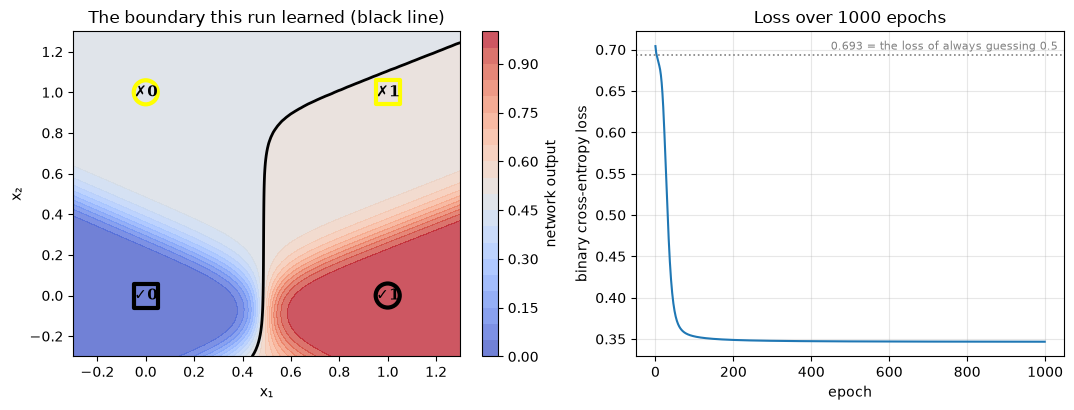

Marked corners: 2 of 4 correct (yellow ring = wrong). Network outputs, in truth-table order: [0.0, 0.5, 1.0, 0.5]
Loss: 0.7042 at epoch 0  →  0.3468 at epoch 999. Over the last 200 epochs it moved by 0.00008 — it has stopped, it did not run out of time.
Reference: a model that always outputs 0.5 scores a loss of 0.693 (the dotted line).


In [5]:
# AFTER training: draw the boundary this run actually learned. The markdown below
# claims the network "settled for the perceptron's answer" — a claim about a shape,
# so it has to be checked as a shape rather than as an accuracy number.
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# --- LEFT: the network's output over the whole input square --------------------
gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 90), np.linspace(-0.3, 1.3, 90))
grid = np.c_[gx.ravel(), gy.ravel()]
zz = model.predict(grid, verbose=0).reshape(gx.shape)      # P(output = 1) everywhere
cf = ax1.contourf(gx, gy, zz, levels=20, cmap="coolwarm", alpha=0.75)
ax1.contour(gx, gy, zz, levels=[0.5], colors="black", linewidths=2)   # the boundary itself
fig.colorbar(cf, ax=ax1, fraction=0.046, label="network output")

# Mark each truth-table row with what the network said and whether it was right.
for (x1, x2), t, p in zip(X_xor, y_xor, predicted_classes):
    ok = (t == p)
    ax1.scatter(x1, x2, s=300, marker="o" if t == 1 else "s",
                facecolor="none", edgecolor="black" if ok else "yellow",
                linewidths=3.0, zorder=3)
    ax1.text(x1, x2, ("\u2713" if ok else "\u2717") + str(int(p)),
             ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)
ax1.set_xlabel("x\u2081")
ax1.set_ylabel("x\u2082")
ax1.set_title("The boundary this run learned (black line)")

# --- RIGHT: did it stop because it converged, or because it ran out of epochs? --
ax2.plot(history.history["loss"], color="tab:blue")
ax2.set_xlabel("epoch")
ax2.set_ylabel("binary cross-entropy loss")
ax2.set_title(f"Loss over {len(history.history['loss'])} epochs")
ax2.grid(alpha=0.3)
ax2.axhline(0.693, color="grey", ls=":", lw=1.2)
ax2.text(len(history.history["loss"]) * 0.45, 0.70,
         "0.693 = the loss of always guessing 0.5", fontsize=8, color="grey")

plt.tight_layout()
plt.show()

# State in numbers what the shapes show, so the caption can be checked.
h = history.history["loss"]
print(f"Marked corners: {int(np.sum(y_xor == predicted_classes))} of 4 correct "
      f"(yellow ring = wrong). Network outputs, in truth-table order: "
      f"{np.round(predictions.flatten(), 3).tolist()}")
print(f"Loss: {h[0]:.4f} at epoch 0  \u2192  {h[-1]:.4f} at epoch {len(h) - 1}. "
      f"Over the last 200 epochs it moved by {abs(h[-1] - h[-200]):.5f} \u2014 it has stopped, "
      f"it did not run out of time.")
print(f"Reference: a model that always outputs 0.5 scores a loss of 0.693 (the dotted line).")


### 📊 What to see in the two panels above

**Left panel — the black curve is the model, and look at what it is doing.** The
hidden layer *did* buy curvature: the boundary is visibly bent, not a straight
perceptron line. And the bend is useless. Follow it through the unit square and it
runs almost vertically at x₁ ≈ 0.5, so every corner is decided by x₁ alone — blue
(output 0) on the left, red (output 1) on the right. A vertical straight line would
classify all four corners identically. **The network paid for the ability to bend
the boundary and then produced the perceptron's answer with it.** The two corners
it got wrong are ringed in yellow with their predicted labels printed on them; for
XOR the red region would have to contain the *diagonal* pair (0,1) and (1,0), and
instead it contains the right-hand pair.

**Right panel — this is not a "needed more epochs" failure.** The loss falls,
flattens, and then stays flat for hundreds of epochs; the printed line reports how
little it moved over the last 200. Training *finished*. It finished in a place
where the network reproduces a straight line, and more epochs from here would
change nothing.

**Put the two panels together and you have the distinction this notebook is for.**
The perceptron could not draw the right shape. This network *could* draw it, and
converged to the wrong one anyway. Same wrong answer on screen, two completely
different causes — and only the picture separates them.



## 📊 Two failures, two different causes

The cell above tried XOR twice, changing the model class:

| model | can it represent XOR? | did it solve XOR? | printed result |
|---|---|---|---|
| Single perceptron | **no** — provably (Minsky & Papert, 1969) | no | flagged before training: "❌ Single perceptron cannot solve XOR" |
| Network with a hidden layer | **yes** | **no, on this run** | **50%** accuracy — 2 of 4 rows correct |

**The conclusion these two rows support — and it is the point of the notebook:**
those are *not the same failure*. The perceptron failed because the right answer
is not inside its hypothesis space; no training procedure could have rescued it.
The network failed with the right answer fully inside its reach, because gradient
descent from this particular random start never found it.

Look at what the network actually settled on: for inputs (0,0), (0,1), (1,0),
(1,1) it output `0, 0, 1, 1` — which is simply the value of the **first** input. That is a straight line. **A model with the capacity to bend
the boundary produced the perceptron's answer anyway**, which is exactly why
"my architecture can represent it" and "my training run found it" have to be
checked separately. Notebook 03 fixes the random seed and reaches 100% with the
same architecture, which settles which of the two problems this run had.


## 💬 Discuss

Read the printed result before answering. The neural network in the cell above
reached **50% accuracy** on XOR: `[0 0] → 0 ✓`, `[0 1] → 0 ✗`, `[1 0] → 1 ✓`,
`[1 1] → 1 ✗`. Two out of four — the same score as a coin flip.

1. That network *has* a hidden layer, so it is capable of representing XOR — and
   it still failed. The next notebook builds the same architecture with a **fixed
   random seed** and reaches 100%. **Is a model that solves the problem on some
   seeds and not others a solution?** Say what you would put in a report, and what
   you would demand from a colleague who showed you only the successful run.
2. Look at what it actually learned: it outputs the value of the *first* input.
   That is a straight line through the plane — the perceptron's answer, produced
   by a network that did not need to settle for it. Argue whether the useful
   lesson here is about XOR, about initialisation, or about how easy it is to
   report a broken run as a working one.
3. Minsky and Papert's proof was right and the field over-generalised from it for
   fifteen years. Name a current claim of the form "neural networks cannot X".
   What evidence would you want before believing it is a property of the method
   rather than of the experiments run so far?


## ⚠️ Where this breaks

**This notebook's own output is the limits section.** The network scored **50%**.
Do not read past that.

- **Small networks on tiny datasets are unstable.** Four training rows and two
  hidden sigmoid units: a large fraction of initialisations drive those two units
  into the flat, near-zero-gradient tails of the sigmoid, and once there gradient
  descent has almost nothing to descend. Left unseeded, this exact cell lands on
  50%, 75% or 100% depending on the machine — so the code pins seed 2, one of the
  initialisations that **fails**. **A reproducible failure is debuggable and an
  irreproducible one is not**, and that is the same reason notebook 03 pins a seed
  for its successful run.
- **Reporting a single run is not reporting a result.** With this much variance,
  the honest report is "accuracy over N seeds: min, median, max", not one number.
  Any comparison of two models where the seed-to-seed spread exceeds the gap
  between them is a comparison of noise.
- **A perceptron cannot solve XOR, and this is not a fixable weakness.** It is a
  statement about what a single linear boundary can represent. The same limit
  applies to logistic regression and to a linear SVM on the same features.
  **Cheaper alternative before reaching for a network:** engineer a feature. Add
  the product `x1 * x2` as a third column and XOR becomes linearly separable — no
  hidden layer needed. Feature engineering and depth solve the same problem, and
  the feature is often cheaper and always more explainable.
- **XOR is not a benchmark.** Four rows, no test set, and train and test are the
  same data. It is a *proof by demonstration* of a representational limit, and it
  says nothing about how any model will behave on real data.
- **`accuracy_score` on 4 samples moves in 25% steps.** There is no meaningful
  difference between 50% and 75% here. Metrics need enough data to have resolution.


## 📚 References

1. Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*. Psychological Review, 65(6), 386–408.
2. Minsky, M., & Papert, S. (1969). *Perceptrons: An Introduction to Computational Geometry*. MIT Press.
3. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. Nature, 323, 533–536.
4. Liu, Z., Wang, Y., Vaidya, S., et al. (2024). *KAN: Kolmogorov-Arnold Networks*. arXiv. <https://arxiv.org/abs/2404.19756>